# Agriculture Yield & Farmer Advisory — A CRISP-DM Breakdown

This notebook walks through the **Agriculture & Extension Services** project using the six CRISP-DM phases:
**Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, and Deployment**.

The project has three connected components:
1. **Phase 1 — Analysis & Insight:** understand how rainfall, inputs, crop and region relate to yield variation.
2. **Phase 2 — Predictive Modelling:** predict a seasonal yield band (Low, Medium, High) from information available before/at the season.
3. **Phase 3 — Farmer Query Text Classification:** classify written farmer queries by crop to support an extension-service query workflow.

**Decision-support principle:** the models provide evidence and predictions for agricultural stakeholders; they do not make agronomic or farm-management decisions automatically.


## 1. Business Understanding

**Goal:** provide an evidence-based decision-support workflow for an agricultural extension programme or county agricultural planning team. The workflow helps the stakeholder understand yield variation, identify the likely yield band for a season, and organize farmer questions by crop.

**Business questions**
- How are rainfall, temperature, pesticide use, crop and region associated with observed yield?
- Can a season's yield be classified into a useful Low/Medium/High band using available structured predictors?
- Can written farmer questions be classified by crop so that queries can be routed or summarized for extension staff?

**Success criteria**
- Phase 1 reports at least two statistical relationships/tests with effect direction and significance.
- Phase 2 evaluates a baseline and predictive models using accuracy and macro-F1, with class-level error analysis.
- Phase 3 evaluates a text classifier using accuracy, macro-F1 and a classification report.
- The workflow clearly separates descriptive evidence from predictions and does not present model output as an automatic recommendation.

**Scope:** Agriculture & Extension Services, with the structured yield analysis and the farmer-query text dataset serving the same agricultural domain. The datasets are **not joined row-by-row by farm ID**; crop and geography are the domain bridge. This limitation must be acknowledged when interpreting cross-dataset findings.


## 2. Data Understanding

### Structured data

The structured source used by this project is the **Dataset for Crop Yield Prediction**. The project uses variables representing:
- crop/item
- year
- area
- rainfall
- pesticide use
- average temperature
- yield

The project records the published source volume separately from the actual dataframe shape. The code below prints the actual rows and columns loaded in the current environment rather than inventing a value.

### Text data

The text component uses the **Digital Green FarmerChat Agricultural Q&A Dataset**, focusing on the Kenya records for the farmer-query classification task. The relevant fields include a written `query`, its `crop` label, response text and geographic/context fields.

The text task is **Route A — text classification**, not open-ended question answering. The ground truth is the dataset's existing crop label.

### Data-quality evidence

The following cells check:
- row/column volume
- variable types
- missingness
- duplicate rows
- numeric ranges
- target/class distribution
- text length
- example queries

Run these cells on the real source files before treating the outputs as final project evidence.


In [ ]:
# Configuration and imports
from pathlib import Path
import sys
import numpy as np
import pandas as pd


In [5]:
# Load structured yield data
from data_utils import load_yield_data, standardize_yield_columns

yield_raw = pd.read_csv('demo_yield.csv')
yield_df = standardize_yield_columns(yield_raw).copy()

print(f"Structured data loaded: {yield_df.shape[0]:,} rows x {yield_df.shape[1]} columns")
display(yield_df.head())
print("\nColumns:")
print(yield_df.columns.tolist())


Structured data loaded: 1,800 rows x 7 columns


,area,year,rainfall_mm_per_year,pesticides_tonnes,avg_temp,crop,yield_hg_ha
0,Kenya,2001,895.2,6.89,19.88,Rice,10848.0
1,Nigeria,2016,1306.0,19.42,26.54,Potatoes,17509.0
2,Nigeria,2013,1069.2,2.65,21.87,Maize,9706.0
3,Ethiopia,2009,760.7,14.44,20.06,Potatoes,17902.0
4,Kenya,2009,765.1,6.58,26.91,Cassava,8138.0



Columns:
['area', 'year', 'rainfall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'crop', 'yield_hg_ha']


In [6]:
# Structured-data volume, variable types, missingness and duplicates
quality = pd.DataFrame({
    "dtype": yield_df.dtypes.astype(str),
    "missing_n": yield_df.isna().sum(),
    "missing_pct": (yield_df.isna().mean() * 100).round(2),
    "unique_n": yield_df.nunique(dropna=True)
}).sort_values("missing_n", ascending=False)

print("Duplicate rows:", int(yield_df.duplicated().sum()))
display(quality)

numeric_cols = yield_df.select_dtypes(include=np.number).columns.tolist()
display(yield_df[numeric_cols].describe().T.round(2))


Duplicate rows: 0


,dtype,missing_n,missing_pct,unique_n
area,object,0,0.0,5
year,int64,0,0.0,21
rainfall_mm_per_year,float64,0,0.0,1658
pesticides_tonnes,float64,0,0.0,1429
avg_temp,float64,0,0.0,1045
crop,object,0,0.0,6
yield_hg_ha,float64,0,0.0,1686


,count,mean,std,min,25%,50%,75%,max
year,1800.0,2010.06,6.07,2000.00,2005.00,2010.00,2015.00,2020.0
rainfall_mm_per_year,1800.0,1103.10,344.68,250.00,863.20,1093.45,1327.50,2200.0
pesticides_tonnes,1800.0,20.43,17.60,0.44,8.72,15.10,25.94,100.0
avg_temp,1800.0,21.95,3.98,10.00,19.41,21.78,24.60,34.0
yield_hg_ha,1800.0,10112.46,3988.28,300.00,7295.75,9417.00,11831.25,21371.0


### Phase 1 exploratory relationships

Two formal statistical analyses are used:
1. **Spearman correlation** for monotonic relationships between yield and numeric environmental/input variables.
2. **Kruskal-Wallis test** to test whether yield distributions differ across crop groups.

These tests describe associations in the observed data. They do **not** establish that changing one variable will cause a particular change in yield.


In [7]:
# Phase 1 statistical relationships
from scipy.stats import spearmanr, kruskal

numeric_predictors = [
    c for c in ["rainfall_mm_per_year", "pesticides_tonnes", "avg_temp", "area", "year"]
    if c in yield_df.columns
]
target = "yield_hg_ha"

spearman_rows = []
for col in numeric_predictors:
    tmp = yield_df[[col, target]].dropna()
    if len(tmp) >= 3 and tmp[col].nunique() > 1:
        rho, p = spearmanr(tmp[col], tmp[target])
        spearman_rows.append({
            "variable": col,
            "n": len(tmp),
            "spearman_rho": rho,
            "p_value": p
        })

spearman_results = pd.DataFrame(spearman_rows).sort_values("p_value")
display(spearman_results.round(4))

if "crop" in yield_df.columns:
    groups = [
        g[target].dropna().values
        for _, g in yield_df.groupby("crop")
        if g[target].notna().sum() >= 2
    ]
    if len(groups) >= 2:
        h_stat, kw_p = kruskal(*groups)
        print(f"Kruskal-Wallis across crop groups: H={h_stat:.3f}, p={kw_p:.6g}")


,variable,n,spearman_rho,p_value
0,rainfall_mm_per_year,1800,0.1903,0.0000
1,pesticides_tonnes,1800,0.0492,0.0370
3,area,1800,0.0333,0.1577
4,year,1800,0.0164,0.4863
2,avg_temp,1800,0.0032,0.8931


Kruskal-Wallis across crop groups: H=1384.586, p=3.01099e-297


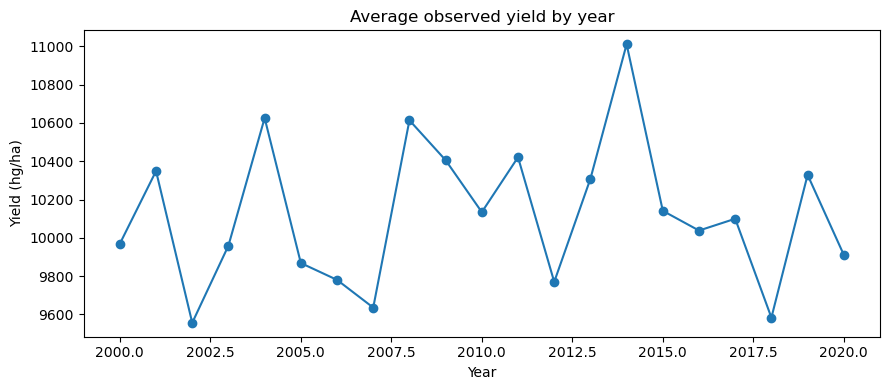

,count,mean,median
crop,,,
Potatoes,298,17349.03,17401.5
Cassava,303,11399.33,11578.0
Rice,308,9694.83,9876.0
Maize,300,8929.48,9067.5
Wheat,302,7304.45,7461.0
Sorghum,289,5908.76,6007.0


In [8]:
# Simple Phase 1 visual evidence
import matplotlib.pyplot as plt

if "year" in yield_df.columns:
    yearly = yield_df.groupby("year")[target].mean()
    yearly.plot(figsize=(9, 4), marker="o")
    plt.title("Average observed yield by year")
    plt.xlabel("Year")
    plt.ylabel("Yield (hg/ha)")
    plt.tight_layout()
    plt.show()

if "crop" in yield_df.columns:
    crop_summary = yield_df.groupby("crop")[target].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
    display(crop_summary.round(2).head(15))


## 3. Data Preparation

The preparation stage is designed to prevent leakage and make the three project components reproducible.

**Structured-data preparation**
- standardize column names and data types
- convert numeric fields safely
- remove rows that cannot support the analysis because the target is missing
- inspect impossible/invalid values rather than silently treating them as valid observations
- retain crop and time/location information where available
- derive the Phase 2 yield band using **training data only**

**Phase 2 leakage control**
The Low/Medium/High thresholds are calculated from the training portion of the data. Test-set information is not used to define the target thresholds.

**Phase 3 text preparation**
- keep substantive farmer queries
- normalize missing/blank text
- retain only sufficiently represented crop labels for a stable student-scale classifier
- split text data stratified by crop
- fit TF-IDF only on the training data


In [9]:
# Prepare the structured data for modelling
model_df = yield_df.copy()

required = [c for c in ["area", "year", "rainfall_mm_per_year",
                        "pesticides_tonnes", "avg_temp", "crop", target]
            if c in model_df.columns]

for col in ["area", "year", "rainfall_mm_per_year", "pesticides_tonnes", "avg_temp", target]:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna(subset=[target]).copy()

print(f"Rows available after target cleaning: {len(model_df):,}")
print("Predictor columns available:", [c for c in required if c != target])


Rows available after target cleaning: 1,800
Predictor columns available: ['area', 'year', 'rainfall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'crop']


## 4. Modeling

### Phase 2 — Predictive model

**Prediction target:** seasonal `yield_band` with three classes:
- Low
- Medium
- High

**Candidate predictors:** area, year, rainfall, pesticide use, average temperature and crop. These provide more than the required five candidate features when the corresponding fields are available.

A **time-aware split** is used where enough years exist: earlier years are used for training and later years for testing. This is more appropriate than randomly mixing future observations into the training set.

Models:
- DummyClassifier — baseline
- Logistic Regression — interpretable linear baseline
- Random Forest — nonlinear ensemble model

Evaluation focuses on **macro-F1 and class-level performance**, not accuracy alone.


In [10]:
# Phase 2: time-aware split and training-data-only yield bands
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

feature_candidates = [
    c for c in ["area", "year", "rainfall_mm_per_year",
                "pesticides_tonnes", "avg_temp", "crop"]
    if c in model_df.columns
]

if "year" in model_df.columns and model_df["year"].nunique() >= 3:
    years = np.sort(model_df["year"].dropna().unique())
    cut_index = max(1, int(len(years) * 0.8) - 1)
    cutoff = years[cut_index]
    train = model_df[model_df["year"] <= cutoff].copy()
    test = model_df[model_df["year"] > cutoff].copy()
else:
    from sklearn.model_selection import train_test_split
    train, test = train_test_split(
        model_df, test_size=0.2, random_state=42, stratify=None
    )

q1, q2 = train[target].quantile([1/3, 2/3])
bins = [-np.inf, q1, q2, np.inf]
labels = ["Low", "Medium", "High"]

train["yield_band"] = pd.cut(train[target], bins=bins, labels=labels, include_lowest=True)
test["yield_band"] = pd.cut(test[target], bins=bins, labels=labels, include_lowest=True)

train = train.dropna(subset=["yield_band"]).copy()
test = test.dropna(subset=["yield_band"]).copy()

print("Train rows:", len(train))
print("Test rows:", len(test))
print("Training thresholds:", {"Low/Medium": float(q1), "Medium/High": float(q2)})
print("\nTraining target distribution:")
print(train["yield_band"].value_counts(normalize=True).round(3))


Train rows: 1359
Test rows: 441
Training thresholds: {'Low/Medium': 8088.666666666666, 'Medium/High': 10837.0}

Training target distribution:
yield_band
Low       0.333
Medium    0.333
High      0.333
Name: proportion, dtype: float64


In [11]:
# Phase 2 preprocessing and model comparison
numeric_features = [c for c in feature_candidates if c != "crop"]
categorical_features = [c for c in feature_candidates if c == "crop"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

X_train = train[feature_candidates]
y_train = train["yield_band"]
X_test = test[feature_candidates]
y_test = test["yield_band"]

models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent", random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced_subsample",
        n_jobs=-1
    )
}

phase2_results = []
phase2_predictions = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    phase2_predictions[name] = pred
    phase2_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro")
    })

phase2_results_df = pd.DataFrame(phase2_results).sort_values("macro_f1", ascending=False)
display(phase2_results_df.round(4))

# Keep the trained models available for later deployment/demo cells.
phase2_pipelines = {}
for name, estimator in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    phase2_pipelines[name] = pipe


,model,accuracy,macro_f1
2,Random Forest,0.7914,0.7894
1,Logistic Regression,0.7528,0.7527
0,Dummy baseline,0.3401,0.1692


### Phase 3 — Farmer query text classification

**Route:** A — supervised text classification.

**Input:** written farmer query.

**Ground truth:** the dataset's existing crop label.

**Output:** predicted crop class. The prototype can return the top predicted classes with probabilities.

This is a routing/classification task. It should not be described as a model that diagnoses pests, recommends chemicals, or provides agronomic treatment advice.


In [12]:
# Load and inspect the FarmerChat text dataset
def load_text_data(use_demo=True):
    path = ROOT / "data" / "demo" / "demo_farmerchat_kenya.csv"
    if not use_demo:
        candidates = [
            ROOT / "data" / "raw" / "farmerchat-queries-v2.csv",
            ROOT / "data" / "raw" / "farmerchat_queries_kenya.csv",
        ]
        for p in candidates:
            if p.exists():
                path = p
                break
    return pd.read_csv(path)

text_df = pd.read_csv('demo_farmerchat_kenya.csv')

text_df["query"] = text_df["query"].astype("string").fillna("").str.strip()
text_df["crop"] = text_df["crop"].astype("string").fillna("").str.strip()
text_df = text_df[(text_df["query"] != "") & (text_df["crop"] != "")].copy()
text_df["word_count"] = text_df["query"].str.split().str.len()

print(f"Text records loaded: {len(text_df):,}")
print(f"Median query word count: {text_df['word_count'].median():.1f}")
print("\nCrop class distribution:")
display(text_df["crop"].value_counts().head(20))
print("\nThree example queries:")
display(text_df[["crop", "query"]].head(3))


Text records loaded: 1,500
Median query word count: 7.0

Crop class distribution:


crop
beans     391
maize     378
tomato    367
potato    364
Name: count, dtype: Int64


Three example queries:


,crop,query
0,beans,Which fertilizer is suitable for beans?
1,potato,How can I control potato blight?
2,maize,How can I control pests affecting my maize crop?


In [13]:
# Phase 3: retain sufficiently represented classes and evaluate
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

counts = text_df["crop"].value_counts()
min_class_n = 100 if len(text_df) >= 5000 else max(20, int(len(text_df) * 0.02))
keep = counts[counts >= min_class_n].index

text_model_df = text_df[text_df["crop"].isin(keep)].copy()

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    text_model_df["query"],
    text_model_df["crop"],
    test_size=0.20,
    random_state=42,
    stratify=text_model_df["crop"]
)

from sklearn.linear_model import LogisticRegression

text_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        sublinear_tf=True
    )),
    ("model", LogisticRegression(max_iter=1500, class_weight="balanced"))
])

text_pipeline.fit(X_text_train, y_text_train)
text_pred = text_pipeline.predict(X_text_test)

phase3_accuracy = accuracy_score(y_text_test, text_pred)
phase3_macro_f1 = f1_score(y_text_test, text_pred, average="macro")

print(f"Phase 3 accuracy: {phase3_accuracy:.4f}")
print(f"Phase 3 macro-F1: {phase3_macro_f1:.4f}")
print("\nClassification report:")
print(classification_report(y_text_test, text_pred, zero_division=0))


Phase 3 accuracy: 1.0000
Phase 3 macro-F1: 1.0000

Classification report:
              precision    recall  f1-score   support

       beans       1.00      1.00      1.00        78
       maize       1.00      1.00      1.00        76
      potato       1.00      1.00      1.00        73
      tomato       1.00      1.00      1.00        73

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## 5. Evaluation

Evaluation is separated from modeling so the final evidence can be interpreted against the business questions.

### Phase 1
- Spearman correlation reports direction, magnitude and p-value.
- Kruskal-Wallis tests whether yield distributions differ across crop groups.
- Visualizations show temporal and crop-level variation.

### Phase 2
- The DummyClassifier establishes a baseline.
- Accuracy and macro-F1 are reported.
- The confusion matrix identifies which yield bands are confused.
- The test period is later than the training period when the data contain enough years.

### Phase 3
- Accuracy and macro-F1 summarize classification performance.
- The classification report provides precision, recall and F1 by crop.
- The ground truth is the dataset crop label, so evaluation measures agreement with that label rather than agronomic correctness.


In [14]:
# Phase 2 confusion matrix and class-level errors
best_phase2_name = phase2_results_df.iloc[0]["model"]
best_phase2_pred = phase2_predictions[best_phase2_name]

print("Phase 2 model used for inspection:", best_phase2_name)
print("\nClassification report:")
print(classification_report(y_test, best_phase2_pred, zero_division=0))

cm = confusion_matrix(y_test, best_phase2_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"Actual {x}" for x in labels],
                     columns=[f"Predicted {x}" for x in labels])
display(cm_df)


Phase 2 model used for inspection: Random Forest

Classification report:
              precision    recall  f1-score   support

        High       0.89      0.83      0.86       150
         Low       0.85      0.82      0.83       158
      Medium       0.64      0.71      0.67       133

    accuracy                           0.79       441
   macro avg       0.79      0.79      0.79       441
weighted avg       0.80      0.79      0.79       441



,Predicted Low,Predicted Medium,Predicted High
Actual Low,129,29,0
Actual Medium,23,95,15
Actual High,0,25,125


In [15]:
# Phase 3 confusion matrix
text_labels = sorted(y_text_test.unique())
cm_text = confusion_matrix(y_text_test, text_pred, labels=text_labels)
cm_text_df = pd.DataFrame(
    cm_text,
    index=[f"Actual {x}" for x in text_labels],
    columns=[f"Predicted {x}" for x in text_labels]
)
display(cm_text_df)


,Predicted beans,Predicted maize,Predicted potato,Predicted tomato
Actual beans,78,0,0,0
Actual maize,0,76,0,0
Actual potato,0,0,73,0
Actual tomato,0,0,0,73


## 6. Deployment

The proposed deployment is a **decision-support extension workflow**, not an autonomous farm-management system.

A practical prototype can expose:
- a Phase 1 dashboard showing yield patterns, crop differences and statistical evidence;
- a Phase 2 prediction form that displays the predicted yield band and model confidence;
- a Phase 3 farmer-query interface that returns the predicted crop category for routing.

**Human oversight:** extension staff remain responsible for interpreting the evidence and deciding what action, if any, is appropriate.

The Phase 3 classifier can be demonstrated with a small function:


In [16]:
# Phase 3 prototype function: top predicted crop classes
def classify_farmer_query(query, top_n=3):
    query = str(query).strip()
    if not query:
        return pd.DataFrame(columns=["crop", "probability"])

    probabilities = text_pipeline.predict_proba([query])[0]
    classes = text_pipeline.named_steps["model"].classes_
    order = np.argsort(probabilities)[::-1][:top_n]

    return pd.DataFrame({
        "crop": classes[order],
        "probability": probabilities[order]
    })

example_query = "My maize leaves are turning yellow and the plants are not growing well."
display(classify_farmer_query(example_query))


,crop,probability
0,maize,0.817095
1,tomato,0.080126
2,potato,0.066684


## 7. Next Steps

1. Run the complete workflow on the **real structured yield dataset** and record the actual row/column counts, missingness and statistical results.
2. Run the Phase 3 workflow on the **real Kenya FarmerChat subset** and record the actual median query length, class distribution and model metrics.
3. Confirm the project approval requirement that the structured and text datasets are sufficiently connected by the agricultural domain/common entities; they are not row-level linked by farm ID.
4. Add stronger temporal validation if the available years support multiple rolling train/test periods.
5. Add calibration and probability checks before using predictions in an operational extension workflow.
6. For agronomic guidance, connect the classifier to reviewed extension materials only after a separate evidence/QA design and evaluation protocol is approved.

**Final interpretation:** this project uses CRISP-DM to move from a bounded agricultural business problem, through evidence-based data understanding and preparation, to predictive and text models, evaluation, and a human-supervised deployment concept.
